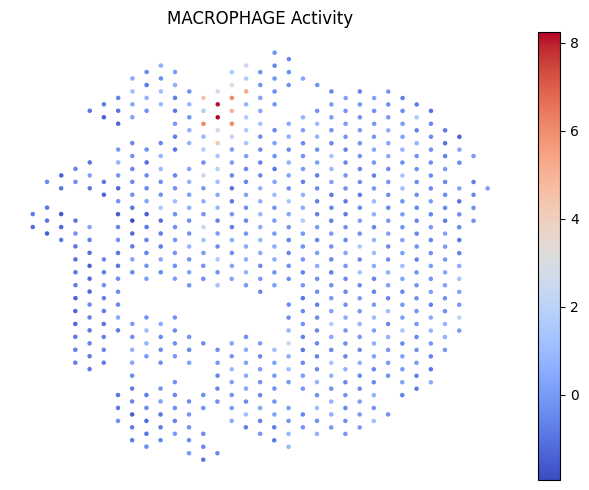

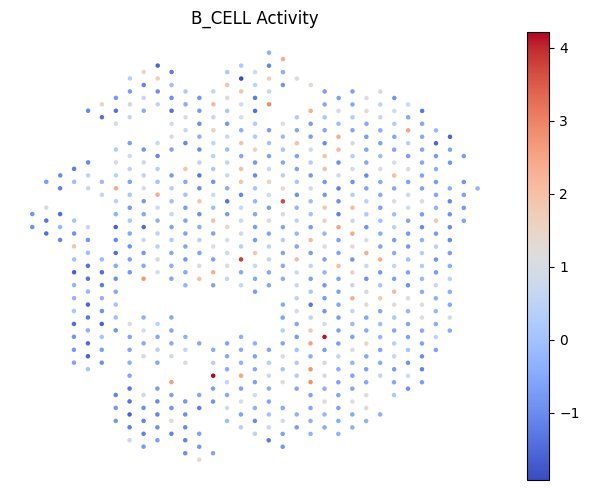

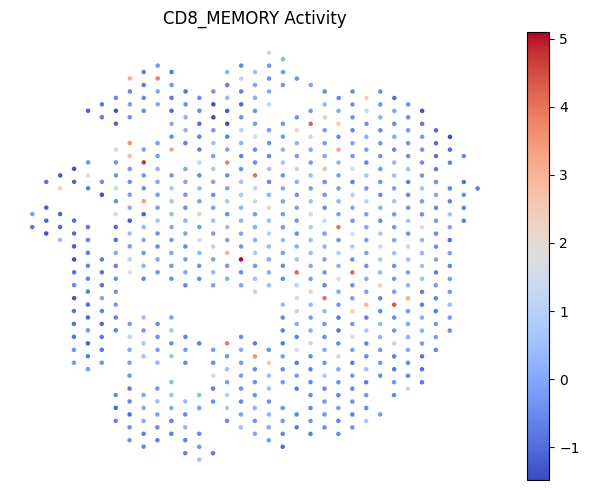

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


'''
(1) spatial pathway heatmap
(2) Moran hotspot classification map
'''

df = pd.read_csv("report.csv")


pathways_to_plot = [
    "MACROPHAGE",
    "B_CELL",
    "CD8_MEMORY"
]


moran_colors = {
    0: "lightgray",   # Not significant
    1: "red",         # High-High
    2: "blue",        # Low-Low
    3: "cyan",        # Low-High
    4: "orange"       # High-Low
}




for pathway in pathways_to_plot:

    plt.figure(figsize=(6, 5))

    sc = plt.scatter(
        df["x"],
        df["y"],
        c=df[pathway],
        cmap="coolwarm",
        s=5
    )

    plt.title(f"{pathway} Activity")
    plt.gca().invert_yaxis()
    plt.axis("off")

    plt.colorbar(sc, fraction=0.046)

    plt.tight_layout()
    plt.show()

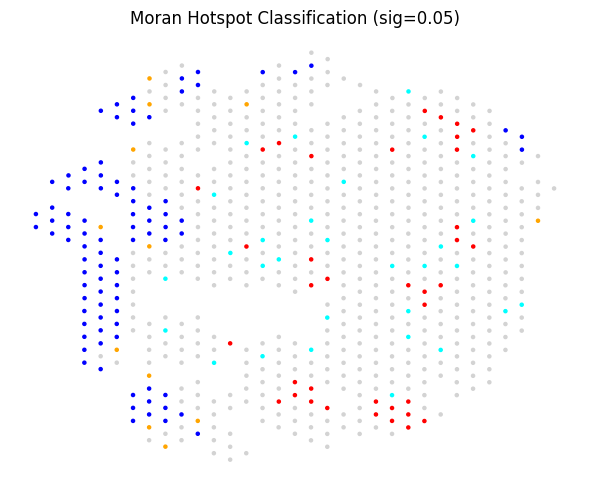

In [2]:
plt.figure(figsize=(6, 5))

colors = df["quad (sig=0.05)"].map(moran_colors)

plt.scatter(
    df["x"],
    df["y"],
    c=colors,
    s=5
)

plt.title("Moran Hotspot Classification (sig=0.05)")
plt.gca().invert_yaxis()
plt.axis("off")

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

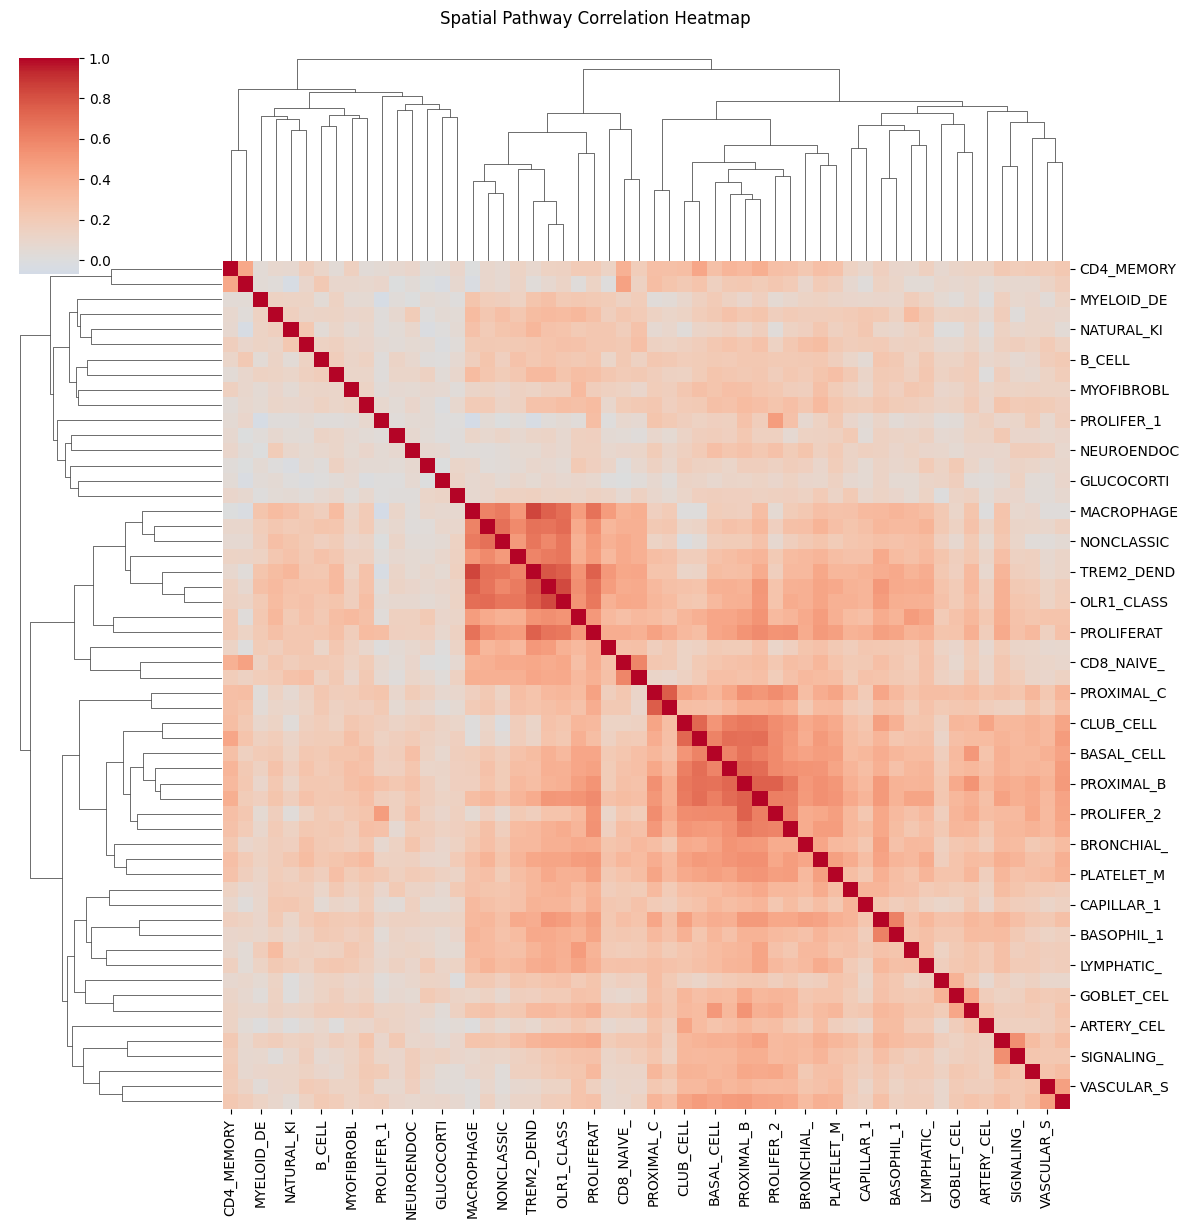

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# 1. Identify pathway columns
# ===============================
exclude_cols = ["barcode", "x", "y", "quad (sig=0.05)", "labels (sig=0.05)"]
pathway_cols = [c for c in df.columns if c not in exclude_cols]

# ===============================
# 2. Compute correlation matrix
# ===============================
corr_matrix = df[pathway_cols].corr(method="pearson")

# ===============================
# 3. Plot heatmap with clustering
# ===============================
plt.figure(figsize=(12,10))

sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(12,12)
)

plt.suptitle("Spatial Pathway Correlation Heatmap", y=1.02)
plt.show()


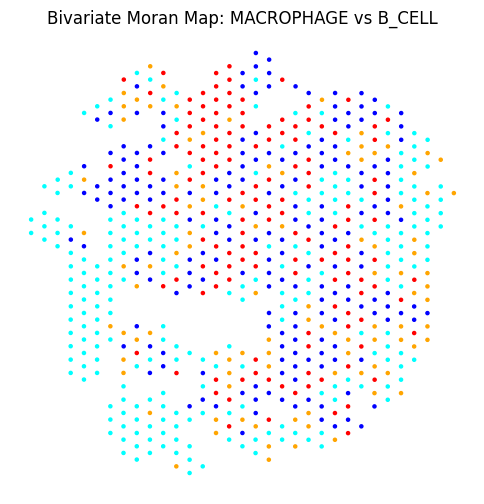

In [4]:
from libpysal.weights import KNN
from esda.moran import Moran_Local_BV
import matplotlib.pyplot as plt

# ===============================
# 1. Choose two pathways
# ===============================
pathway_A = "MACROPHAGE"
pathway_B = "B_CELL"

# ===============================
# 2. Build spatial neighbors
# ===============================
coords = list(zip(df["x"], df["y"]))
w = KNN.from_array(coords, k=6)
w.transform = "r"

# ===============================
# 3. Compute Bivariate Moran
# ===============================
values_A = df[pathway_A].values
values_B = df[pathway_B].values

moran_bv = Moran_Local_BV(values_A, values_B, w)

df["biv_quad"] = moran_bv.q
df["biv_pval"] = moran_bv.p_sim

# ===============================
# 4. Color mapping
# ===============================
biv_colors = {
    0: "lightgray",
    1: "red",     # High A - High B
    2: "blue",    # Low A - Low B
    3: "cyan",    # Low A - High B
    4: "orange"   # High A - Low B
}

colors = df["biv_quad"].map(biv_colors)

# ===============================
# 5. Plot spatial map
# ===============================
plt.figure(figsize=(6,6))

plt.scatter(
    df["x"],
    df["y"],
    c=colors,
    s=5
)

plt.gca().invert_yaxis()
plt.title(f"Bivariate Moran Map: {pathway_A} vs {pathway_B}")
plt.axis("off")

plt.show()


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from libpysal.weights import KNN
from esda.moran import Moran_Local_BV




df = pd.read_csv("report.csv")

output_dir = "images"
os.makedirs(output_dir, exist_ok=True)

pathways_to_plot = [
    "MACROPHAGE",
    "B_CELL",
    "CD8_MEMORY"
]

moran_colors = {
    0: "lightgray",
    1: "red",
    2: "blue",
    3: "cyan",
    4: "orange"
}


# ==========================================
# Spatial Pathway Heatmaps
# ==========================================

for pathway in pathways_to_plot:

    plt.figure(figsize=(6, 5))

    sc = plt.scatter(
        df["x"],
        df["y"],
        c=df[pathway],
        cmap="coolwarm",
        s=5
    )

    plt.title(f"{pathway} Activity")
    plt.gca().invert_yaxis()
    plt.axis("off")
    plt.colorbar(sc, fraction=0.046)

    save_path = os.path.join(
        output_dir,
        f"heatmap_{pathway}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()



# ==========================================
# Moran Hotspot Classification Map
# ==========================================

plt.figure(figsize=(6, 5))

colors = df["quad (sig=0.05)"].map(moran_colors)

plt.scatter(
    df["x"],
    df["y"],
    c=colors,
    s=5
)

plt.title("moran_classification.png")
plt.gca().invert_yaxis()
plt.axis("off")

save_path = os.path.join(
    output_dir,
    "moran_classification.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()



# ==========================================
# Spatial Pathway Correlation Heatmap
# ==========================================

exclude_cols = ["barcode", "x", "y", "quad (sig=0.05)", "labels (sig=0.05)"]
pathway_cols = [c for c in df.columns if c not in exclude_cols]

corr_matrix = df[pathway_cols].corr(method="pearson")

cluster = sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(12, 12)
)

cluster.fig.suptitle("Spatial Pathway Correlation Heatmap")

save_path = os.path.join(
    output_dir,
    "correlation_heatmap.png"
)

cluster.savefig(save_path, dpi=300)
plt.close()



# ==========================================
# Bivariate Moran Map
# ==========================================

pathway_A = "MACROPHAGE"
pathway_B = "B_CELL"

coords = list(zip(df["x"], df["y"]))
w = KNN.from_array(coords, k=6)
w.transform = "r"

values_A = df[pathway_A].values
values_B = df[pathway_B].values

moran_bv = Moran_Local_BV(values_A, values_B, w)

df["biv_quad"] = moran_bv.q

biv_colors = {
    0: "lightgray",
    1: "red",
    2: "blue",
    3: "cyan",
    4: "orange"
}

colors = df["biv_quad"].map(biv_colors)

plt.figure(figsize=(6, 6))

plt.scatter(
    df["x"],
    df["y"],
    c=colors,
    s=5
)

plt.gca().invert_yaxis()
plt.title(f"bivariate_moran_{pathway_A}_vs_{pathway_B}")
plt.axis("off")

save_path = os.path.join(
    output_dir,
    f"bivariate_moran_{pathway_A}_vs_{pathway_B}.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()



print("All images saved to 'images/' directory.")


All images saved to 'images/' directory.


In [7]:
import pandas as pd
import numpy as np
from scipy.ndimage import label
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local_BV


# =====================================================
# Load Data
# =====================================================

df = pd.read_csv("report.csv")

pathway_A = "MACROPHAGE"
pathway_B = "B_CELL"
pathway_C = "CD8_MEMORY"


# =====================================================
# Clustered Pattern Test
# =====================================================

def eval_clustered_pattern(df, pathway, threshold=0.2):

    coords = list(zip(df["x"], df["y"]))
    w = KNN.from_array(coords, k=6)
    w.transform = "r"

    moran = Moran(df[pathway].values, w)

    return {
        "moran_I": moran.I,
        "is_clustered": moran.I > threshold
    }


# =====================================================
# Gradient Pattern Test
# =====================================================

def eval_gradient_pattern(df, pathway, threshold=0.3):

    values = df[pathway].values
    corr_x = np.corrcoef(values, df["x"])[0,1]
    corr_y = np.corrcoef(values, df["y"])[0,1]

    max_corr = max(abs(corr_x), abs(corr_y))

    return {
        "corr_x": corr_x,
        "corr_y": corr_y,
        "has_gradient": max_corr > threshold
    }


# =====================================================
# Domain Count Estimation
# =====================================================

def eval_domain_count(df, pathway):

    values = df[pathway].values
    threshold = np.percentile(values, 80)

    mask = values > threshold
    labeled, num_regions = label(mask)

    return {
        "num_high_activity_regions": int(num_regions)
    }


# =====================================================
# Significant Hotspot Presence
# =====================================================

def eval_hotspot_presence(df, threshold=10):

    hh_count = np.sum(df["quad (sig=0.05)"] == 1)

    return {
        "HH_count": int(hh_count),
        "hotspots_present": hh_count > threshold
    }


# =====================================================
# Dominant Structure Type
# =====================================================

def eval_dominant_structure(df):

    hh_count = np.sum(df["quad (sig=0.05)"] == 1)
    ll_count = np.sum(df["quad (sig=0.05)"] == 2)

    return {
        "HH_count": int(hh_count),
        "LL_count": int(ll_count),
        "hotspot_dominant": hh_count > ll_count
    }


# =====================================================
# Boundary Structure Presence
# =====================================================

def eval_boundary_presence(df, threshold=0.05):

    hl = np.sum(df["quad (sig=0.05)"] == 4)
    lh = np.sum(df["quad (sig=0.05)"] == 3)
    total = len(df)

    proportion = (hl + lh) / total

    return {
        "boundary_proportion": proportion,
        "boundary_present": proportion > threshold
    }


# =====================================================
# Functional Module Presence
# =====================================================

def eval_functional_module(df, corr_threshold=0.6):

    exclude_cols = ["barcode", "x", "y", "quad (sig=0.05)", "labels (sig=0.05)"]
    pathway_cols = [c for c in df.columns if c not in exclude_cols]

    corr_matrix = df[pathway_cols].corr()

    strong = np.sum(np.abs(corr_matrix.values) > corr_threshold) - len(pathway_cols)

    return {
        "num_strong_correlations": int(strong),
        "module_present": strong > 0
    }


# =====================================================
# Antagonistic Pair Presence
# =====================================================

def eval_antagonistic_pairs(df, neg_threshold=-0.3):

    exclude_cols = ["barcode", "x", "y", "quad (sig=0.05)", "labels (sig=0.05)"]
    pathway_cols = [c for c in df.columns if c not in exclude_cols]

    corr_matrix = df[pathway_cols].corr()

    neg_pairs = np.sum(corr_matrix.values < neg_threshold)

    return {
        "num_negative_pairs": int(neg_pairs),
        "antagonism_present": neg_pairs > 0
    }


# =====================================================
# Spatial Co-localization
# =====================================================

def eval_spatial_colocalization(df, pathway_A, pathway_B, threshold=0.1):

    coords = list(zip(df["x"], df["y"]))
    w = KNN.from_array(coords, k=6)
    w.transform = "r"

    moran_bv = Moran_Local_BV(
        df[pathway_A].values,
        df[pathway_B].values,
        w
    )

    hh_prop = np.sum(moran_bv.q == 1) / len(df)

    return {
        "HH_proportion": hh_prop,
        "colocalized": hh_prop > threshold
    }


# =====================================================
# Spatial Antagonism
# =====================================================

def eval_spatial_antagonism(df, pathway_A, pathway_B):

    coords = list(zip(df["x"], df["y"]))
    w = KNN.from_array(coords, k=6)
    w.transform = "r"

    moran_bv = Moran_Local_BV(
        df[pathway_A].values,
        df[pathway_B].values,
        w
    )

    hl_lh = np.sum((moran_bv.q == 3) | (moran_bv.q == 4))
    hh = np.sum(moran_bv.q == 1)

    return {
        "HL_LH_count": int(hl_lh),
        "HH_count": int(hh),
        "antagonistic": hl_lh > hh
    }


# =====================================================
# Run All Benchmarks
# =====================================================

results = {
    "Clustered_MACROPHAGE": eval_clustered_pattern(df, pathway_A),
    "Gradient_MACROPHAGE": eval_gradient_pattern(df, pathway_A),
    "DomainCount_MACROPHAGE": eval_domain_count(df, pathway_A),

    "HotspotPresence": eval_hotspot_presence(df),
    "DominantStructure": eval_dominant_structure(df),
    "BoundaryPresence": eval_boundary_presence(df),

    "FunctionalModule": eval_functional_module(df),
    "AntagonisticPairs": eval_antagonistic_pairs(df),

    "Colocalization_MACROPHAGE_vs_B_CELL":
        eval_spatial_colocalization(df, pathway_A, pathway_B),

    "Antagonism_MACROPHAGE_vs_B_CELL":
        eval_spatial_antagonism(df, pathway_A, pathway_B)
}

for k, v in results.items():
    print(k, ":", v)


Clustered_MACROPHAGE : {'moran_I': 0.5273328099101958, 'is_clustered': True}
Gradient_MACROPHAGE : {'corr_x': 0.09800302602226434, 'corr_y': -0.1858291001440361, 'has_gradient': False}
DomainCount_MACROPHAGE : {'num_high_activity_regions': 91}
HotspotPresence : {'HH_count': 37, 'hotspots_present': True}
DominantStructure : {'HH_count': 37, 'LL_count': 89, 'hotspot_dominant': False}
BoundaryPresence : {'boundary_proportion': 0.0637329286798179, 'boundary_present': True}
FunctionalModule : {'num_strong_correlations': 78, 'module_present': True}
AntagonisticPairs : {'num_negative_pairs': 0, 'antagonism_present': False}
Colocalization_MACROPHAGE_vs_B_CELL : {'HH_proportion': 0.212443095599393, 'colocalized': True}
Antagonism_MACROPHAGE_vs_B_CELL : {'HL_LH_count': 328, 'HH_count': 140, 'antagonistic': True}


In [ ]:
'''
GPT's answer: 
1. Yes
2. No
3. 21
4. Yes
5. No
6. Yes
7. Yes
8. No
9. Yes
10. Yes
'''

In [8]:
import pandas as pd
import numpy as np
from libpysal.weights import KNN
import networkx as nx


# ==========================================
# Load Data
# ==========================================

df = pd.read_csv("report.csv")


# ==========================================
# Helper: Build Spatial Graph
# ==========================================

def build_spatial_graph(df, k=6):
    coords = list(zip(df["x"], df["y"]))
    w = KNN.from_array(coords, k=k)

    G = nx.Graph()

    for i in range(len(df)):
        G.add_node(i)

    for i, neighbors in w.neighbors.items():
        for j in neighbors:
            G.add_edge(i, j)

    return G


# ==========================================
# HH Region Count
# ==========================================

def eval_hh_region_count(df):

    G = build_spatial_graph(df)

    hh_nodes = df.index[df["quad (sig=0.05)"] == 1].tolist()

    subgraph = G.subgraph(hh_nodes)
    components = list(nx.connected_components(subgraph))

    return {
        "benchmark": "HH Region Count",
        "num_HH_regions": len(components)
    }


# ==========================================
# Dominant HH Structure
# ==========================================

def eval_dominant_hh_structure(df):

    G = build_spatial_graph(df)

    hh_nodes = df.index[df["quad (sig=0.05)"] == 1].tolist()
    total_hh = len(hh_nodes)

    if total_hh == 0:
        return {
            "benchmark": "Dominant HH Structure",
            "largest_HH_ratio": 0,
            "dominant": False
        }

    subgraph = G.subgraph(hh_nodes)
    components = list(nx.connected_components(subgraph))

    largest_size = max(len(c) for c in components)
    ratio = largest_size / total_hh

    return {
        "benchmark": "Dominant HH Structure",
        "largest_HH_ratio": ratio,
        "dominant": ratio > 0.5
    }


# ==========================================
# Boundary Proportion Test
# ==========================================

def eval_boundary_proportion(df, threshold=0.10):

    hl = np.sum(df["quad (sig=0.05)"] == 4)
    lh = np.sum(df["quad (sig=0.05)"] == 3)
    total = len(df)

    boundary_ratio = (hl + lh) / total

    return {
        "benchmark": "Boundary Proportion Test",
        "boundary_ratio": boundary_ratio,
        "boundary_present": boundary_ratio > threshold
    }


# ==========================================
# Run Benchmarks
# ==========================================

results = [
    eval_hh_region_count(df),
    eval_dominant_hh_structure(df),
    eval_boundary_proportion(df)
]

for r in results:
    print(r)


{'benchmark': 'HH Region Count', 'num_HH_regions': 13}
{'benchmark': 'Dominant HH Structure', 'largest_HH_ratio': 0.21621621621621623, 'dominant': False}
{'benchmark': 'Boundary Proportion Test', 'boundary_ratio': 0.0637329286798179, 'boundary_present': False}


In [ ]:
'''
GPT's answer:
1. 2
2. No
3. No

'''